## **Phi_4 with free boundary conditions**



## **I. Setup and Preprocessing**

In [1]:
# Import os library to access environment variables and operating system functionalities
import os

# Set environment variable to avoid duplicate library errors, specifically for OpenMP
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
# Set TensorFlow log level to '2' to suppress most messages except warnings and errors
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
sys.path.append("../utilities")

# Import necessary libraries for deep learning and numerical computation
import tensorflow as tf
import numpy as np
from SREINet import * 
import DataGenerator as DG


# Print a formatted message to the terminal to display current time, date, and TensorFlow version
print("**********************************************")
print("*                                            *")
print("*    Tensorflow Version: " + tf.__version__ + "              *")
print("*                                            *")
print("**********************************************")

from packaging import version
if version.parse(tf.__version__) < version.parse('2.10.0') and version.parse(tf.__version__) > version.parse('2.15.0'):
    print("Error: Tensorflow version is lower than 2.10.0 or higher than 2.15.0 Please use Tensorflow 2.10.0 - 2.15.0")
    sys.exit()

MY_DATA_TYPE = 'float32'
# Set the desired data type
tf.keras.backend.set_floatx(MY_DATA_TYPE)  


**********************************************
*                                            *
*    Tensorflow Version: 2.15.0              *
*                                            *
**********************************************


### **1.2 Training Data**

#### Create dataset

Guess highest order polynomial: 3
(7500, 20)


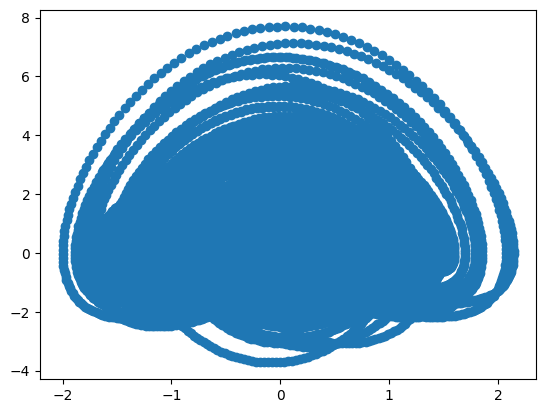

Training input shape: (7500, 20)
Training output shape: (7500, 20)


In [2]:
# Specify the model type
MY_MODEL = 'discrete_phi_quartic' 

SEED = 42  # set seed for random number generation
np.random.seed(SEED)


# Generate data based on the specified model type
node_num = 10 # number of nodes
C = 2.0 #coupling strength

#initial conditions for Simulation
xn = np.linspace(-node_num/2/np.sqrt(C), node_num/2/np.sqrt(C), node_num)

num_traj = 3
data_initial_conditions= []
for i in range(num_traj):

        x0 = np.random.normal(0, 0.1, size=xn.shape)  # random initial position
        d_x0 = np.random.normal(0, 0.1, size=xn.shape)  # random initial velocity

        new_IC = np.concatenate((x0, d_x0), axis=0) 
        data_initial_conditions.append(new_IC)

data_T =  25.0       # Length of the data (T)
data_dt = 0.01     # Resolution of the data (dt)
myDG = DG.DataGenerator(data_initial_conditions,T=data_T, dt=data_dt, random_state=SEED)

t_arr, x_train, dx_train, guess_highest_order_polynomial = myDG.generate_dataset_by_model_name(MY_MODEL, C, node_num, method='DOP853')

print("Guess highest order polynomial:", guess_highest_order_polynomial)

#plot x_train and dx_train
import matplotlib.pyplot as plt
print(x_train.shape)
plt.scatter(x_train, dx_train)
plt.show()

#Shuffle data
training_input, training_output = x_train, dx_train

print("Training input shape:", training_input.shape)
print("Training output shape:", training_output.shape)

### **1.3 Hyperparameters**



In [3]:
# Set mini-batch size
MINI_BATCH_SIZE = 64
learning_rate = 0.01

### **1.4 Model Architecture Definitions**

**SREINet Parameters**


In [4]:
# Assign dim to be the 2nd dimension of the training data (number of input variables, including the added constant 1)
dim = training_input.shape[1] 

# The grid size of each dimension
layer_depth = guess_highest_order_polynomial
layer_neuron_nums_per_act_fn = [dim] * layer_depth
print(layer_neuron_nums_per_act_fn) # excluding the constant term; NOT the total number of neurons per layer

[20, 20, 20]


## **II. Model and Training Preparation**


### **2.1 Create the SREINet Model**


In [5]:
activation_fns = [lambda x:x]
inputs = tf.keras.layers.Input(shape=(dim,), dtype=MY_DATA_TYPE)
model = SREINet(layer_neuron_nums_per_act_fn, 
                     activations=activation_fns,
                     data_type=MY_DATA_TYPE,
                     weight_initializer=tf.initializers.random_normal(stddev=1e-4, seed=SEED),
                     name='SREINet')
output = model(inputs)
model = tf.keras.Model(inputs=inputs, outputs=output)


### **2.2 Loss Function**

In [6]:
LOSS_FUNCTION = 'mse' #This can be 'MSE', 'LASSO', or 'RIDGE' or 'ElasticNet'(case insensitive)
 
from loss import *

# Example of selecting a loss function
loss_fn = myLoss(model, LOSS_FUNCTION) 

### **2.3 Optimizer**

In [7]:
my_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)  # Create an Adam optimizer with the defined learning rate

### **2.4 trainer**


In [8]:
from sreinet_trainer import *

trainer = SREINetTrainer(model, my_optimizer, loss_fn, data_type='float32')

## **III.Training the Model**


#### **Pruning Profile**


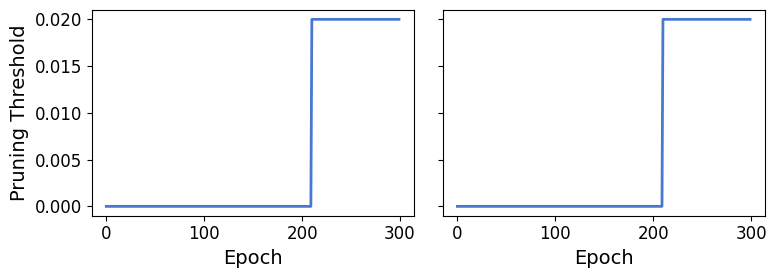

In [9]:
MAX_WEIGHT_PRUNING_THRESHOLD = 0.02 #.3-.35 
N_PERIODS = 1
PRUNING_EPOCHS_PER_PERIOD = 300
NUM_EPOCHS = PRUNING_EPOCHS_PER_PERIOD * N_PERIODS

import pruning_scheduler as ps

pruning_scheduler = ps.PruningScheduler(steps_per_period=PRUNING_EPOCHS_PER_PERIOD, 
                    num_periods=N_PERIODS,
                    maximum_threshold=MAX_WEIGHT_PRUNING_THRESHOLD,
                    zero_percentage=0.7,
                    ramp_percentage=0.0,
                    show_plot=True)


In [10]:
callbacks = []

EARLY_STOPPING_LOSS_THRESHOLD = 1e-10   # Threshold for early stopping (Layer Based)
EARLY_STOPPING_PRUNING_THRESHOLD = 0.00

training_histories = []
weights_list = []
loss_list = []


In [11]:
print(f"Total Dimensions: {training_output.shape[1]}")
for i in range(0,training_output.shape[1]):
    print(f"Training dimension {i + 1}...")
    
    output = training_output[:, i:i+1]
    
    history = trainer.fit(training_input, output,
     batch_size=MINI_BATCH_SIZE, 
     validation_split=0.20,
     epochs=round(NUM_EPOCHS), 
     pruning_scheduler=pruning_scheduler,
     early_stopping_loss_threshold=EARLY_STOPPING_LOSS_THRESHOLD,
     early_stopping_pruning_threshold=EARLY_STOPPING_PRUNING_THRESHOLD,
     patience_periods=15,
     verbose=1,
    )
    training_histories.append(history)

    # Retrieve the weights of the trained model
    weights_list.append([trainer.get_best_weights()])
    loss_list.append(trainer.get_best_loss())

    #reset the model and trainer
    trainer.reset_trainer_and_model_weights(i)

Total Dimensions: 20
Training dimension 1...
Epoch   1 (Period 1):  Train Loss: 7.570e-02,  Validation Loss: 4.769e-03,  Epoch Time: 0.32s,  Current Pruning Threshold: 0
Epoch   2 (Period 1):  Train Loss: 2.383e-03,  Validation Loss: 1.019e-03,  Epoch Time: 0.08s,  Current Pruning Threshold: 0
Epoch   3 (Period 1):  Train Loss: 7.618e-04,  Validation Loss: 8.556e-04,  Epoch Time: 0.08s,  Current Pruning Threshold: 0
Epoch   4 (Period 1):  Train Loss: 5.461e-04,  Validation Loss: 5.757e-04,  Epoch Time: 0.08s,  Current Pruning Threshold: 0
Epoch   5 (Period 1):  Train Loss: 4.755e-04,  Validation Loss: 5.427e-04,  Epoch Time: 0.08s,  Current Pruning Threshold: 0
Epoch   6 (Period 1):  Train Loss: 9.403e-04,  Validation Loss: 8.594e-04,  Epoch Time: 0.08s,  Current Pruning Threshold: 0
Epoch   7 (Period 1):  Train Loss: 7.206e-04,  Validation Loss: 1.280e-03,  Epoch Time: 0.08s,  Current Pruning Threshold: 0
Epoch   8 (Period 1):  Train Loss: 7.027e-04,  Validation Loss: 2.488e-04,  Epoc

## **IV. Coefficient Reconstructor (SREINet)**



#### `generate_set_labels`

In [12]:
def generate_LHS_labels(N):
    return [f"(x{i})'" for i in range(1, N+1)]

def generate_layer_labels(N):
    return ['Constant'] + [f'x{i}' for i in range(1, N+1)]

#### `coefficient_reconstruction`


In [13]:
from coefficient_reconstructor import *
cr = CoefficientReconstructor(generate_layer_labels, generate_LHS_labels)

## **V. Results Display**
### **Identified Model**

In [14]:
eq_str = []
for i in range(len(weights_list)):
    path_products = cr.reconstruct_coefficients(i,
                                               weights_list[i], 
                                            minimum_coefficient_threshold = 1e-3,
                                            coefficient_output_digits = 10, 
                                            enable_coefficient_sorting = False)
    
    for index, dimension in enumerate(path_products):
        print(f"{dimension}")
        eq_str.append(dimension)

(x1)' = 0.9999959127*x11
(x2)' = 1.000050882*x12
(x3)' = 0.9984858315*x13 + 0.002463190651*x1*x13 - 0.005528111207*x13*x3 - 0.002847005317*x13*x8 + 0.002597733996*x1*x13*x3 + 0.00143699256*x1*x13*x8 - 0.003008743398*x13*x3^2 - 0.003328683815*x13*x3*x8 - 0.001296486243*x12*x2*x4
(x4)' = 0.001160929688*x13 + 0.001735313839*x13*x5 - 0.002021524174*x13*x9 + 0.001341392781*x10*x13 + 0.9999803457*x14 - 0.001188842592*x13*x2 - 0.001777036994*x13*x2*x5 + 0.002070128849*x13*x2*x9 - 0.001373644664*x10*x13*x2 + 0.001336424279*x13*x3*x5 - 0.001556844604*x13*x3*x9 + 0.001033052259*x10*x13*x3 + 0.001171497956*x13*x6 + 0.001751110888*x13*x5*x6 - 0.002039926675*x13*x6*x9 + 0.001353603856*x10*x13*x6
(x5)' = 1.000171854*x15
(x6)' = 0.9999999335*x16
(x7)' =  - 0.00421426281*x6 - 0.002216201207*x3*x6 - 0.004710187812*x4*x6 - 0.001600231953*x5*x6 - 0.003572161102*x6*x8 + 0.001232582471*x10*x6 + 0.003649386268*x11*x6 - 0.001112885481*x12*x6 + 0.001552958436*x14*x6 - 0.006266824227*x15*x6 + 0.00251393909*x17

### **Validation**


In [15]:
import model_reconstructor as mr

recovered_model = mr.RecoveredModel()
recovered_model.parse_ode_equations(eq_str);


### Comparing vector field

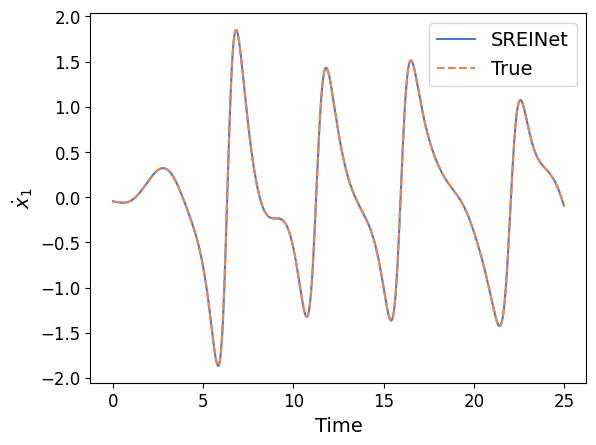

In [16]:
pred_x_dot = recovered_model.predict_derivatives(x_train)

val_t_span = [0,data_T]
val_t_eval = np.arange(0,data_T,data_dt)

import matplotlib.pyplot as plt

plt.plot(val_t_eval, pred_x_dot[:val_t_eval.shape[0], 0],label='SREINet')
plt.plot(val_t_eval, dx_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel(r'$\dot{x}_1$')
plt.legend()
plt.show()


### Comparing response

In [17]:
val_t_span = [0,100]
val_t_eval = np.arange(0,100,data_dt)

validation_result = recovered_model.simulate(data_initial_conditions[0], t_span=val_t_span,t_eval=val_t_eval, method='DOP853')

ValueError: x and y must have same first dimension, but have shapes (10000,) and (7500,)

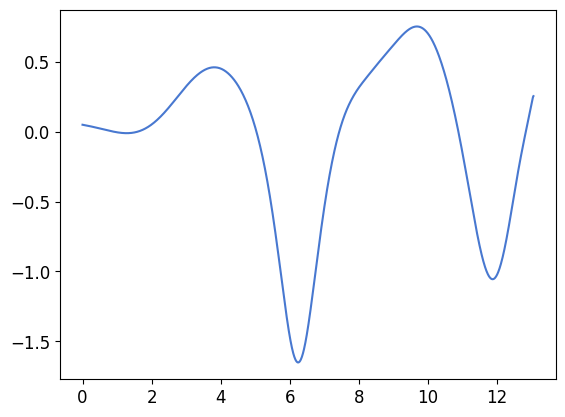

In [18]:
import matplotlib.pyplot as plt

plt.plot(validation_result['t'], validation_result['y'][0],label='SREINet')
plt.plot(val_t_eval, x_train[:val_t_eval.shape[0],0], '--', label='True')
plt.xlabel('Time')
plt.ylabel('x1')
plt.legend()
plt.show()



In [ ]:
score =recovered_model.score(x_train[:val_t_eval.shape[0]], dx_train[:val_t_eval.shape[0]])
print(f"Score: {score}")

complexity = recovered_model.calculate_complexity()
print(f"Complexity: {complexity}")

complexity_per_dimension = complexity // dim
print(f"complexity per dimension: {complexity_per_dimension}")


Score: 0.99999999999988
Complexity: 246
complexity per dimension: 2


## **VI. Output**

In [ ]:
#save hyperparameters
import pandas as pd

df = pd.DataFrame({
    'ODE model': [MY_MODEL],
    'data initial conditions': [data_initial_conditions],
    'data length (T)': [data_T],
    'data resolution (dt)': [data_dt],
    'learning rate': [learning_rate],
    'layer depth': [layer_depth],
    'input dimension': [x_train.shape[1]],
    'mini_batch_size': [MINI_BATCH_SIZE],
    'Layer Neurons per activation fns': [layer_neuron_nums_per_act_fn],
    'Data Points': [training_input.shape[0]],
    'Total Training Epochs': [NUM_EPOCHS],
    'loss function': [LOSS_FUNCTION],
    'Best loss values': [str(loss_list)], 
    'max weight threshold for pruning': [MAX_WEIGHT_PRUNING_THRESHOLD],
    'loss threshold for early stopping': [EARLY_STOPPING_LOSS_THRESHOLD],
    'pruning epochs per period': [PRUNING_EPOCHS_PER_PERIOD],
    'number of training periods': [N_PERIODS],
})

In [ ]:
# Import the output helper module
import output_helper as opt_helper

# Save all results to Excel using the helper function
filepath = opt_helper.save_sreinet_results_to_excel(
    config_df=df,
    training_histories=training_histories,
    recovered_model=recovered_model,
    filename='Phi4_nn_configurations.xlsx',
    output_dir='output'
)

Successfully saved SREINet results to: output/Phi4_nn_configurations.xlsx
